# Initial SNP Poster Summary
This notebook summarizes G-related ClinVar SNP overlaps in QGRS motifs for `TSS`, `5'UTR`, and `3'UTR` regions from the `initial_snp` stage. It creates poster-friendly tables and figures in `initial_snp_poster_outputs/`.

In [1]:
from pathlib import Path
import os

PROJECT_ROOT = Path("/Users/ritika/Desktop/pilot")
OUTPUT_DIR = PROJECT_ROOT / "initial_snp_poster_outputs"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
MPL_DIR = OUTPUT_DIR / ".matplotlib"

for path in [OUTPUT_DIR, FIG_DIR, TABLE_DIR, MPL_DIR]:
    path.mkdir(parents=True, exist_ok=True)

os.environ["MPLCONFIGDIR"] = str(MPL_DIR)

import pandas as pd
import matplotlib.pyplot as plt

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    plt.style.use("ggplot")

plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

REGION_INFO = {
    "TSS": {
        "all": PROJECT_ROOT / "initial_snp" / "tss_snp" / "tss_upstream500_reference.clinvar_snps.tsv",
        "g": PROJECT_ROOT / "initial_snp" / "tss_snp" / "tss_upstream500_reference.clinvar_g_related_snps.tsv",
    },
    "5'UTR": {
        "all": PROJECT_ROOT / "initial_snp" / "5utr_snp" / "5utr_reference.clinvar_snps.tsv",
        "g": PROJECT_ROOT / "initial_snp" / "5utr_snp" / "5utr_reference.clinvar_g_related_snps.tsv",
    },
    "3'UTR": {
        "all": PROJECT_ROOT / "initial_snp" / "3utr_snp" / "3utr_reference.clinvar_snps.tsv",
        "g": PROJECT_ROOT / "initial_snp" / "3utr_snp" / "3utr_reference.clinvar_g_related_snps.tsv",
    },
}

REGION_ORDER = ["TSS", "5'UTR", "3'UTR"]

Matplotlib is building the font cache; this may take a moment.


In [2]:
def load_tsv(path, region_label, is_g_related):
    df = pd.read_csv(path, sep="\t")
    df["REGION_GROUP"] = region_label
    df["SOURCE_SET"] = "G-related only" if is_g_related else "All ClinVar overlaps"
    df["CLNSIG_PRIMARY"] = (
        df["CLNSIG"].fillna("")
        .astype(str)
        .str.split("|").str[0]
        .str.split(",").str[0]
        .replace("", "not_reported")
    )
    return df

all_frames = []
g_frames = []
for region_label, paths in REGION_INFO.items():
    all_frames.append(load_tsv(paths["all"], region_label, False))
    g_frames.append(load_tsv(paths["g"], region_label, True))

all_overlaps = pd.concat(all_frames, ignore_index=True)
g_overlaps = pd.concat(g_frames, ignore_index=True)

print(f"All ClinVar overlaps: {len(all_overlaps):,}")
print(f"G-related overlaps: {len(g_overlaps):,}")
print(f"Unique genes with G-related overlaps: {g_overlaps['GENE'].nunique():,}")

g_overlaps.head()

All ClinVar overlaps: 2,018
G-related overlaps: 1,351
Unique genes with G-related overlaps: 259


,SEQUENCE_ID,QGRS_ID,GENE,GENE_NO,TRANSCRIPT,STRAND,COSMIC,REGION,CHROM,QGRS_GENOMIC_START_1BASED,...,CLNSIG,CLNDN,RS,ALLELEID,CLNVC,GENEINFO,REGION_GROUP,SOURCE_SET,CLNSIG_PRIMARY,GENOMIC_INTERVALS
0,72,2,BMPR1A,72,ENST00000372037.8,+,COSG95149,TSS_UPSTREAM500(+),chr10,86756273,...,Likely_benign,not_provided,1.120216e+07,1184413,single_nucleotide_variant,BMPR1A:657|LOC130004245:130004245,TSS,G-related only,Likely_benign,NaN
1,548,1,PTEN,552,ENST00000371953.8,+,COSG93969,TSS_UPSTREAM500(+),chr10,87863218,...,Uncertain_significance,not_provided|Familial_meningioma|Prostate_canc...,1.554890e+09,481888,single_nucleotide_variant,PTEN:5728|KLLN:100144748,TSS,G-related only,Uncertain_significance,NaN
2,548,1,PTEN,552,ENST00000371953.8,+,COSG93969,TSS_UPSTREAM500(+),chr10,87863218,...,Uncertain_significance,PTEN-related_disorder|Hereditary_cancer-predis...,7.275028e+08,133123,single_nucleotide_variant,PTEN:5728|KLLN:100144748,TSS,G-related only,Uncertain_significance,NaN
3,548,1,PTEN,552,ENST00000371953.8,+,COSG93969,TSS_UPSTREAM500(+),chr10,87863218,...,Uncertain_significance,not_provided|PTEN_hamartoma_tumor_syndrome,5.877800e+08,172161,single_nucleotide_variant,PTEN:5728|KLLN:100144748,TSS,G-related only,Uncertain_significance,NaN
4,548,1,PTEN,552,ENST00000371953.8,+,COSG93969,TSS_UPSTREAM500(+),chr10,87863218,...,Uncertain_significance,not_specified,NaN,3525808,single_nucleotide_variant,PTEN:5728|KLLN:100144748,TSS,G-related only,Uncertain_significance,NaN


In [3]:
summary_rows = []
for region in REGION_ORDER:
    all_df = all_overlaps[all_overlaps["REGION_GROUP"] == region]
    g_df = g_overlaps[g_overlaps["REGION_GROUP"] == region]
    change_counts = g_df["G_CHANGE_CLASS"].value_counts()
    summary_rows.append(
        {
            "region": region,
            "all_clinvar_overlaps": len(all_df),
            "g_related_overlaps": len(g_df),
            "pct_g_related": round(100 * len(g_df) / len(all_df), 1) if len(all_df) else 0.0,
            "unique_genes_with_g_related_snps": g_df["GENE"].nunique(),
            "unique_qgrs_motifs_with_g_related_snps": g_df[["REGION_GROUP", "SEQUENCE_ID", "QGRS_ID"]].drop_duplicates().shape[0],
            "from_G_count": int(change_counts.get("from_G", 0)),
            "to_G_count": int(change_counts.get("to_G", 0)),
        }
    )

region_summary = pd.DataFrame(summary_rows)
region_summary.to_csv(TABLE_DIR / "initial_snp_region_summary.tsv", sep="\t", index=False)
region_summary

,region,all_clinvar_overlaps,g_related_overlaps,pct_g_related,unique_genes_with_g_related_snps,unique_qgrs_motifs_with_g_related_snps,from_G_count,to_G_count
0,TSS,442,307,69.5,68,84,245,62
1,5'UTR,602,406,67.4,146,184,318,88
2,3'UTR,974,638,65.5,173,435,500,138


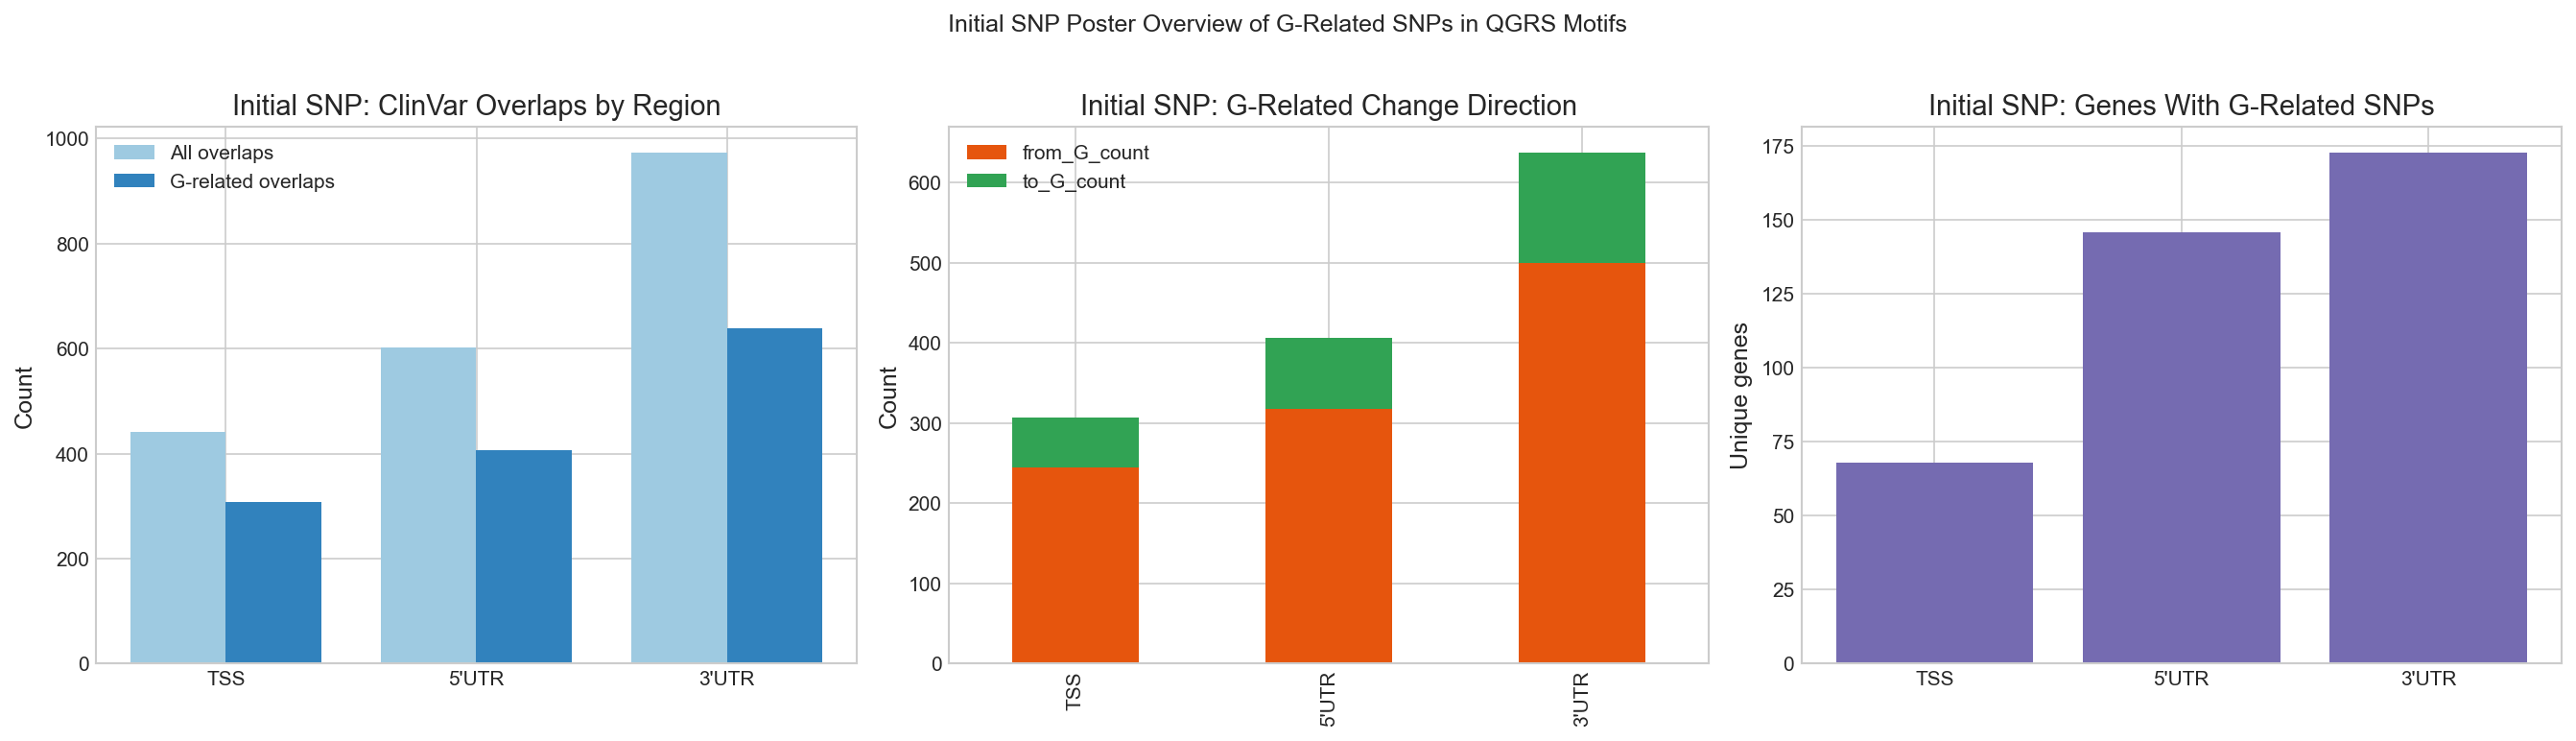

PosixPath('/Users/ritika/Desktop/pilot/initial_snp_poster_outputs/figures/initial_snp_region_overview.png')

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = range(len(region_summary))
width = 0.38
axes[0].bar([i - width / 2 for i in x], region_summary["all_clinvar_overlaps"], width=width, label="All overlaps", color="#9ecae1")
axes[0].bar([i + width / 2 for i in x], region_summary["g_related_overlaps"], width=width, label="G-related overlaps", color="#3182bd")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(region_summary["region"])
axes[0].set_title("Initial SNP: ClinVar Overlaps by Region")
axes[0].set_ylabel("Count")
axes[0].legend(frameon=False)

change_plot = region_summary.set_index("region")[["from_G_count", "to_G_count"]]
change_plot.plot(kind="bar", stacked=True, ax=axes[1], color=["#e6550d", "#31a354"])
axes[1].set_title("Initial SNP: G-Related Change Direction")
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")
axes[1].legend(frameon=False)

axes[2].bar(region_summary["region"], region_summary["unique_genes_with_g_related_snps"], color="#756bb1")
axes[2].set_title("Initial SNP: Genes With G-Related SNPs")
axes[2].set_ylabel("Unique genes")

fig.suptitle("Initial SNP Poster Overview of G-Related SNPs in QGRS Motifs", y=1.02)
fig.tight_layout()
overview_path = FIG_DIR / "initial_snp_region_overview.png"
fig.savefig(overview_path, bbox_inches="tight")
plt.show()
overview_path

REGION_GROUP,3'UTR,5'UTR,TSS,total_g_related_snps
GENE,,,,
MSH2,0,22,61,83
PTEN,0,21,60,81
RB1,0,30,23,53
TSC2,14,4,33,51
BRCA2,0,35,1,36
MLH1,0,0,30,30
STK11,18,5,1,24
TSC1,20,3,0,23
VHL,12,6,4,22


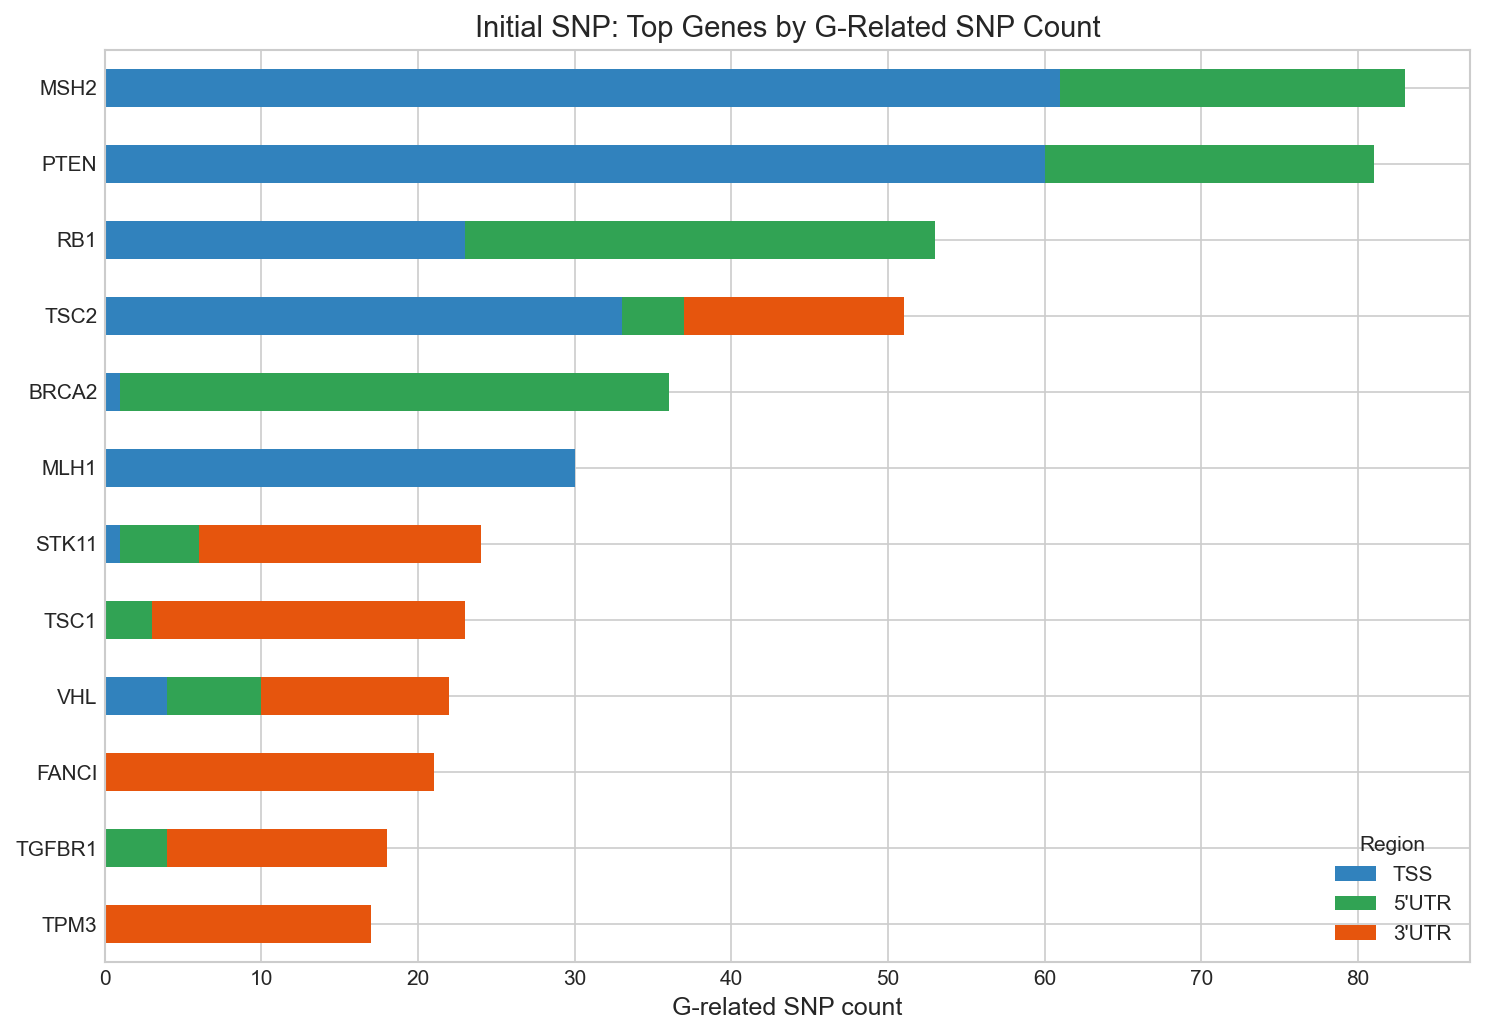

PosixPath('/Users/ritika/Desktop/pilot/initial_snp_poster_outputs/figures/initial_snp_top_genes_by_region.png')

In [5]:
gene_region_counts = (
    g_overlaps.groupby(["GENE", "REGION_GROUP"]).size().reset_index(name="g_related_snp_count")
)

gene_totals = (
    gene_region_counts.groupby("GENE")["g_related_snp_count"].sum().sort_values(ascending=False)
)
top_genes = gene_totals.head(12).index

top_gene_table = (
    gene_region_counts[gene_region_counts["GENE"].isin(top_genes)]
    .pivot(index="GENE", columns="REGION_GROUP", values="g_related_snp_count")
    .fillna(0)
    .astype(int)
    .reindex(top_genes)
)
top_gene_table["total_g_related_snps"] = top_gene_table.sum(axis=1)
top_gene_table.to_csv(TABLE_DIR / "initial_snp_top_genes_by_region.tsv", sep="\t")

display(top_gene_table)

plot_df = top_gene_table[REGION_ORDER].iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 7))
plot_df.plot(kind="barh", stacked=True, ax=ax, color=["#3182bd", "#31a354", "#e6550d"])
ax.set_title("Initial SNP: Top Genes by G-Related SNP Count")
ax.set_xlabel("G-related SNP count")
ax.set_ylabel("")
ax.legend(title="Region", frameon=False)
fig.tight_layout()
top_genes_path = FIG_DIR / "initial_snp_top_genes_by_region.png"
fig.savefig(top_genes_path, bbox_inches="tight")
plt.show()
top_genes_path

REGION_GROUP,3'UTR,5'UTR,TSS
CLNSIG_PRIMARY,,,
Uncertain_significance,307,204,213
Benign,142,49,28
Likely_benign,77,90,44
not_reported,47,27,2
Conflicting_classifications_of_pathogenicity,30,26,12
Benign/Likely_benign,29,8,3
Likely_pathogenic,1,1,2
not_provided,3,0,1


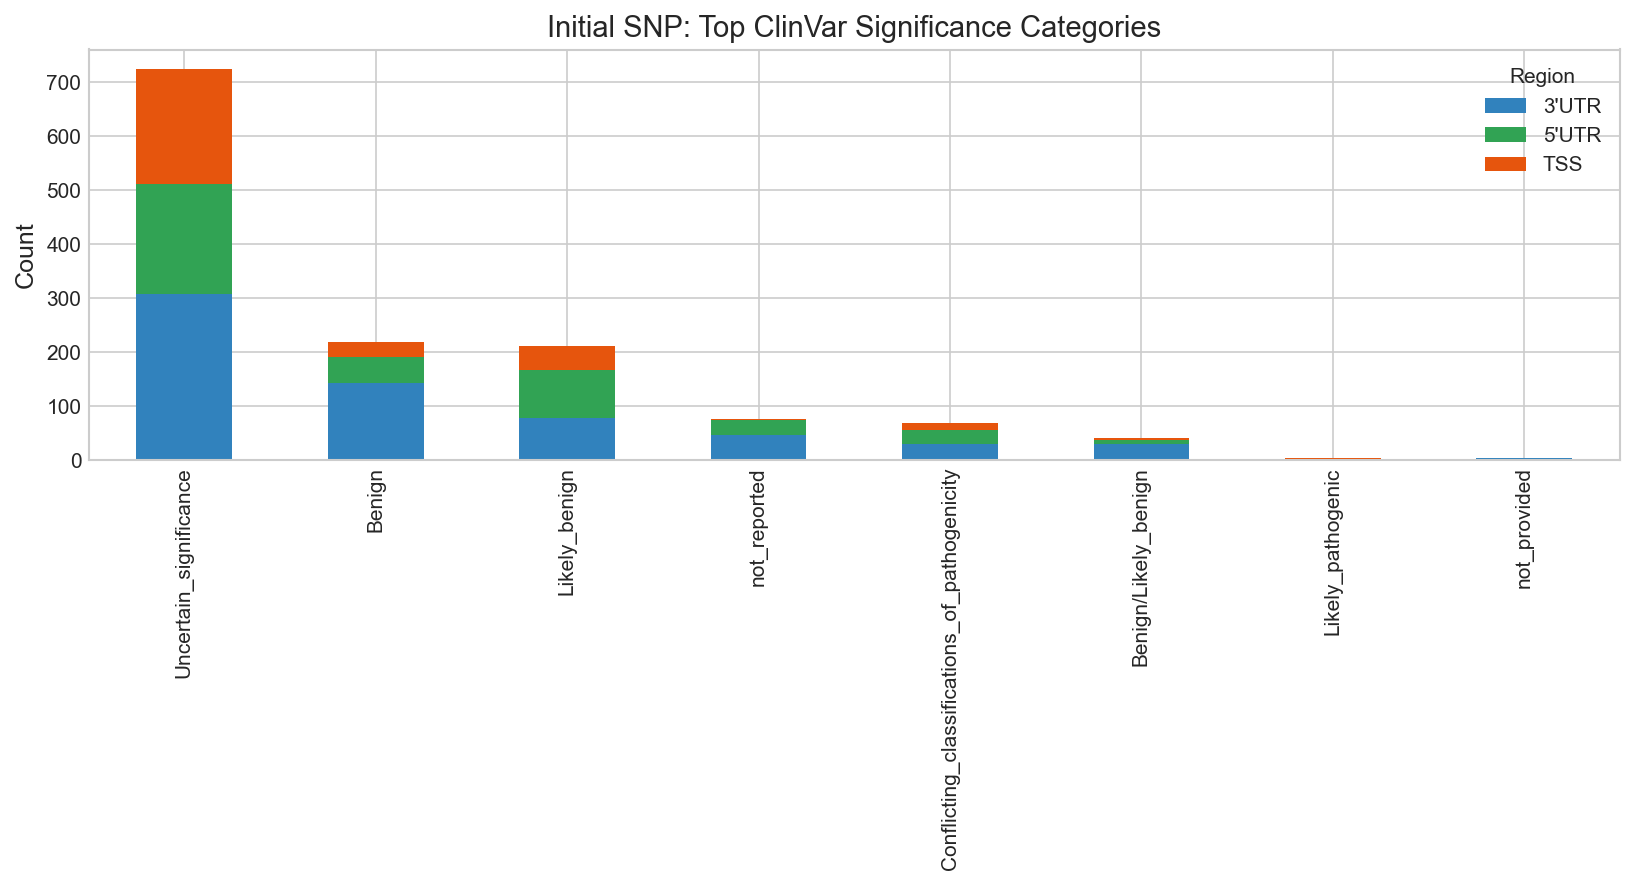

PosixPath('/Users/ritika/Desktop/pilot/initial_snp_poster_outputs/figures/initial_snp_top_clinsig_categories.png')

In [6]:
clnsig_counts = (
    g_overlaps.groupby(["CLNSIG_PRIMARY", "REGION_GROUP"]).size().reset_index(name="count")
)

top_clnsig = (
    clnsig_counts.groupby("CLNSIG_PRIMARY")["count"].sum().sort_values(ascending=False).head(8).index
)

clnsig_table = (
    clnsig_counts[clnsig_counts["CLNSIG_PRIMARY"].isin(top_clnsig)]
    .pivot(index="CLNSIG_PRIMARY", columns="REGION_GROUP", values="count")
    .fillna(0)
    .astype(int)
    .loc[top_clnsig]
)
clnsig_table.to_csv(TABLE_DIR / "initial_snp_top_clinsig_categories.tsv", sep="\t")

display(clnsig_table)

fig, ax = plt.subplots(figsize=(11, 6))
clnsig_table.plot(kind="bar", stacked=True, ax=ax, color=["#3182bd", "#31a354", "#e6550d"])
ax.set_title("Initial SNP: Top ClinVar Significance Categories")
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.legend(title="Region", frameon=False)
fig.tight_layout()
clnsig_path = FIG_DIR / "initial_snp_top_clinsig_categories.png"
fig.savefig(clnsig_path, bbox_inches="tight")
plt.show()
clnsig_path

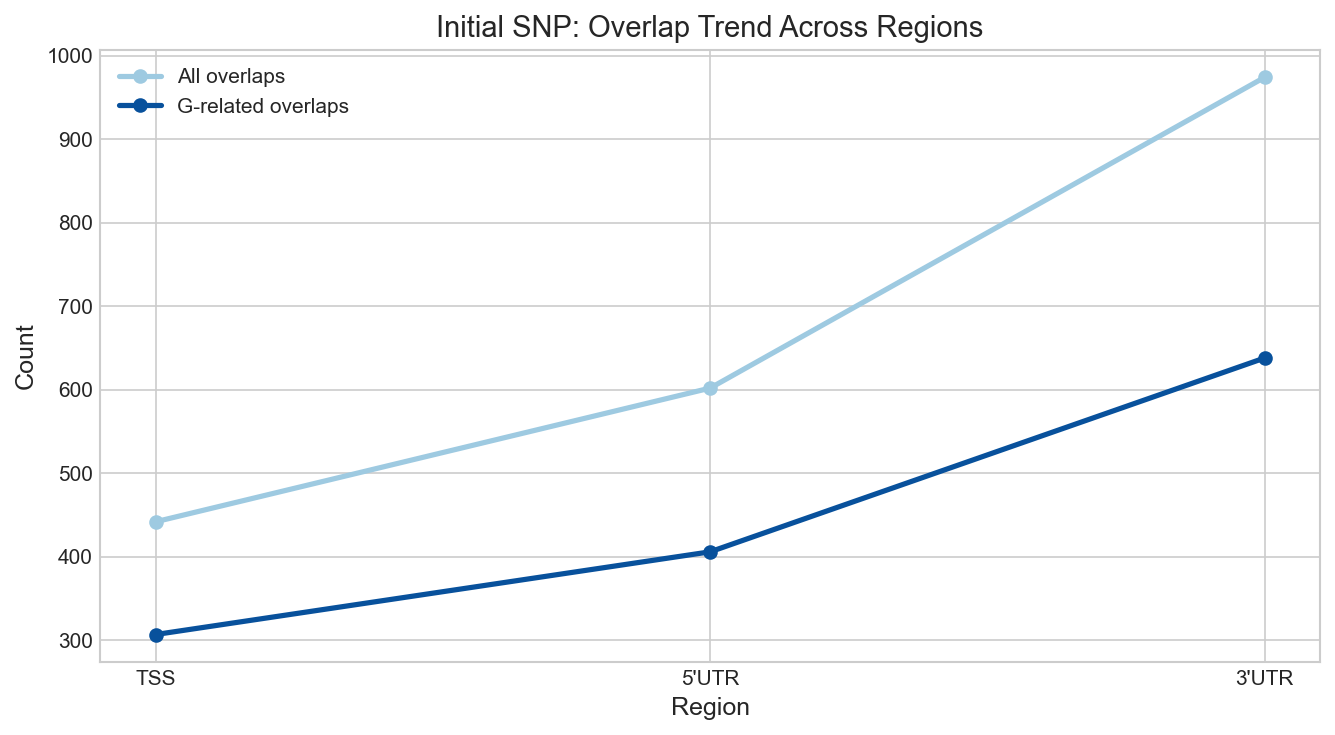

PosixPath('/Users/ritika/Desktop/pilot/initial_snp_poster_outputs/figures/initial_snp_overlap_trend.png')

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
line_df = region_summary[["region", "all_clinvar_overlaps", "g_related_overlaps"]].copy()
ax.plot(line_df["region"], line_df["all_clinvar_overlaps"], marker="o", linewidth=2.5, color="#9ecae1", label="All overlaps")
ax.plot(line_df["region"], line_df["g_related_overlaps"], marker="o", linewidth=2.5, color="#08519c", label="G-related overlaps")
ax.set_title("Initial SNP: Overlap Trend Across Regions")
ax.set_xlabel("Region")
ax.set_ylabel("Count")
ax.legend(frameon=False)
fig.tight_layout()
line_region_path = FIG_DIR / "initial_snp_overlap_trend.png"
fig.savefig(line_region_path, bbox_inches="tight")
plt.show()
line_region_path

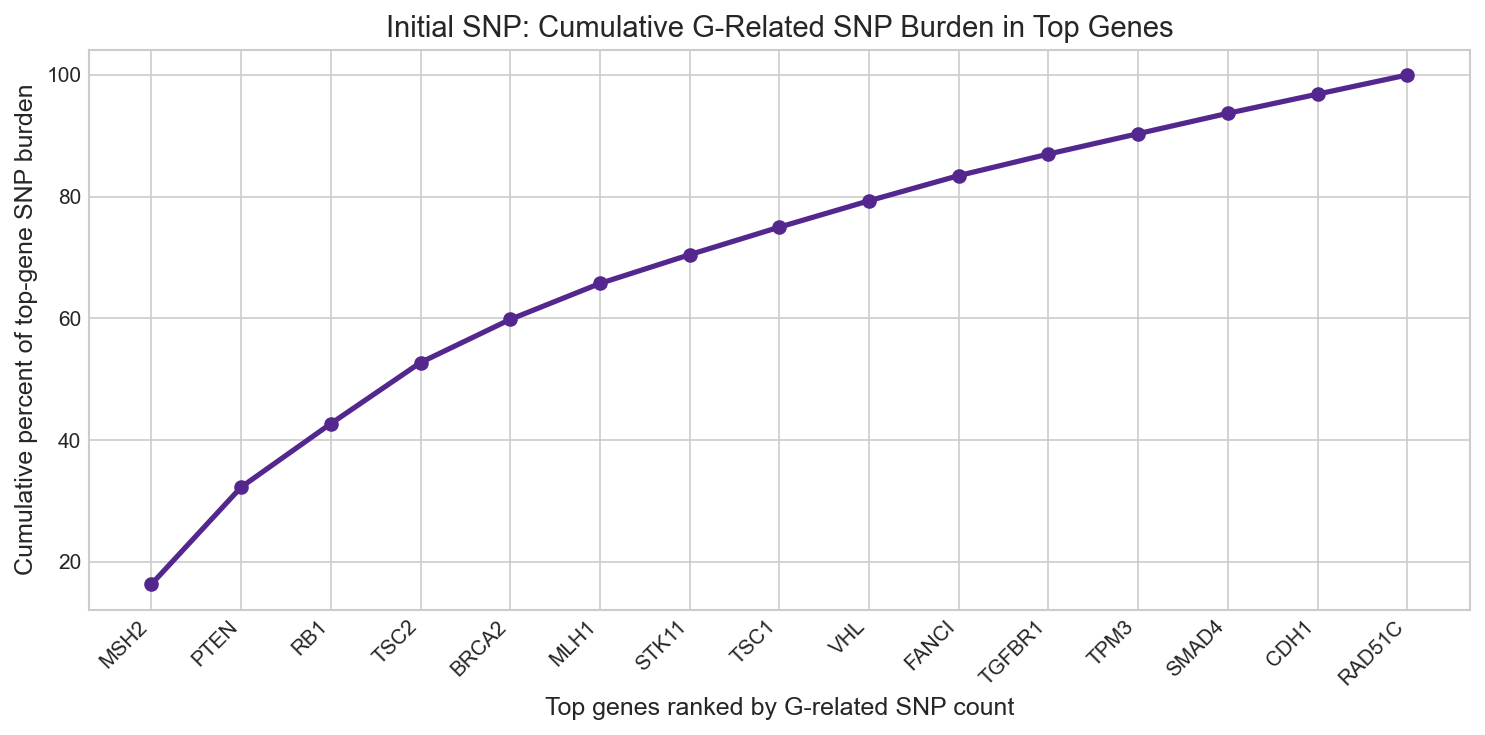

PosixPath('/Users/ritika/Desktop/pilot/initial_snp_poster_outputs/figures/initial_snp_cumulative_top_genes.png')

In [ ]:
top_gene_line = gene_totals.head(15).sort_values(ascending=False)
cumulative = top_gene_line.cumsum() / top_gene_line.sum() * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumulative) + 1), cumulative.values, marker="o", linewidth=2.5, color="#54278f")
ax.set_xticks(range(1, len(cumulative) + 1))
ax.set_xticklabels(top_gene_line.index, rotation=45, ha="right")
ax.set_title("Initial SNP: Cumulative G-Related SNP Burden in Top Genes")
ax.set_xlabel("Top genes ranked by G-related SNP count")
ax.set_ylabel("Cumulative percent of top-gene SNP burden")
fig.tight_layout()
line_gene_path = FIG_DIR / "initial_snp_cumulative_top_genes.png"
fig.savefig(line_gene_path, bbox_inches="tight")
plt.show()
line_gene_path

In [ ]:
saved_figures = sorted(FIG_DIR.glob("*.png"))
saved_tables = sorted(TABLE_DIR.glob("*.tsv"))

print("Saved figures:")
for path in saved_figures:
    print(f"- {path}")

print("\nSaved tables:")
for path in saved_tables:
    print(f"- {path}")

Saved figures:
- /Users/ritika/Desktop/pilot/initial_snp_poster_outputs/figures/initial_snp_cumulative_top_genes.png
- /Users/ritika/Desktop/pilot/initial_snp_poster_outputs/figures/initial_snp_overlap_trend.png
- /Users/ritika/Desktop/pilot/initial_snp_poster_outputs/figures/initial_snp_region_overview.png
- /Users/ritika/Desktop/pilot/initial_snp_poster_outputs/figures/initial_snp_top_clinsig_categories.png
- /Users/ritika/Desktop/pilot/initial_snp_poster_outputs/figures/initial_snp_top_genes_by_region.png

Saved tables:
- /Users/ritika/Desktop/pilot/initial_snp_poster_outputs/tables/initial_snp_region_summary.tsv
- /Users/ritika/Desktop/pilot/initial_snp_poster_outputs/tables/initial_snp_top_clinsig_categories.tsv
- /Users/ritika/Desktop/pilot/initial_snp_poster_outputs/tables/initial_snp_top_genes_by_region.tsv


In [ ]:
saved_figures = sorted(FIG_DIR.glob("*.png"))
saved_tables = sorted(TABLE_DIR.glob("*.tsv"))

print("Saved figures:")
for path in saved_figures:
    print(f"- {path}")

print("\nSaved tables:")
for path in saved_tables:
    print(f"- {path}")

Saved figures:
- /Users/ritika/Desktop/pilot/initial_snp_poster_outputs/figures/initial_snp_cumulative_top_genes.png
- /Users/ritika/Desktop/pilot/initial_snp_poster_outputs/figures/initial_snp_overlap_trend.png
- /Users/ritika/Desktop/pilot/initial_snp_poster_outputs/figures/initial_snp_region_overview.png
- /Users/ritika/Desktop/pilot/initial_snp_poster_outputs/figures/initial_snp_top_clinsig_categories.png
- /Users/ritika/Desktop/pilot/initial_snp_poster_outputs/figures/initial_snp_top_genes_by_region.png

Saved tables:
- /Users/ritika/Desktop/pilot/initial_snp_poster_outputs/tables/initial_snp_region_summary.tsv
- /Users/ritika/Desktop/pilot/initial_snp_poster_outputs/tables/initial_snp_top_clinsig_categories.tsv
- /Users/ritika/Desktop/pilot/initial_snp_poster_outputs/tables/initial_snp_top_genes_by_region.tsv
